# Notebook CCA — Projection dans un espace commun + Géométrie
## Stratégie
1. Extraire des embeddings text (sentence-transformers) et image (ResNet-18) — **frozen, pas d'entraînement**
2. **CCA (Canonical Correlation Analysis)** : apprend à projeter text et image dans le même espace en maximisant leur corrélation sur les paires cohérentes
3. Calculer des **features géométriques riches** dans cet espace commun
4. Entraîner un classifieur classique sur ces features


In [2]:
# Cell 1 — Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cross_decomposition import PLSCanonical
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.utils import shuffle
import warnings
warnings.filterwarnings('ignore')

import subprocess
subprocess.run(["pip", "install", "sentence-transformers", "Pillow", "--quiet"], check=True)

from sentence_transformers import SentenceTransformer
from PIL import Image
import torch
import torchvision.models as tv_models
import torchvision.transforms as transforms

print("Tous les imports OK.")


Tous les imports OK.


In [3]:
# Cell 2 — Chargement données
DATA_DIR = '../data/processed'

def load_split(split_name):
    texts, img_paths, labels = [], [], []
    for label, cat in enumerate(['incoherent', 'coherent']):
        folder = os.path.join(DATA_DIR, split_name, cat)
        if not os.path.exists(folder):
            print(f"Dossier {folder} non trouvé. Skipping.")
            continue
        for f in sorted(os.listdir(folder)):
            if f.endswith('.txt'):
                with open(os.path.join(folder, f), 'r', encoding='utf-8') as fh:
                    texts.append(fh.read().strip())
                img_paths.append(os.path.join(folder, f.replace('.txt', '.jpg')))
                labels.append(label)
    texts, img_paths, labels = shuffle(texts, img_paths,
                                       np.array(labels), random_state=42)
    return np.array(texts), np.array(img_paths), labels

print("Chargement des splits...")
t_train, p_train, y_train = load_split('train')
t_val,   p_val,   y_val   = load_split('validation')
t_test,  p_test,  y_test  = load_split('test')

print(f"Train: {len(t_train)} | Val: {len(t_val)} | Test: {len(t_test)}")
print(f"Balance train: {np.bincount(y_train)}")


Chargement des splits...
Train: 7000 | Val: 1500 | Test: 1500
Balance train: [3505 3495]


In [4]:
# Cell — Embeddings texte (TF-IDF + SVD, no download needed)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import numpy as np

print("Encodage textes (TF-IDF + SVD)...")
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
svd = TruncatedSVD(n_components=384, random_state=42)

# Fit on train, transform all
E_text_train = svd.fit_transform(tfidf.fit_transform(t_train))
E_text_val   = svd.transform(tfidf.transform(t_val))
E_text_test  = svd.transform(tfidf.transform(t_test))

# L2 normalize
for emb in [E_text_train, E_text_val, E_text_test]:
    emb[:] = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)

print(f"Shape embeddings texte: {E_text_train.shape}")  # (7000, 384)

Encodage textes (TF-IDF + SVD)...
Shape embeddings texte: (7000, 384)


In [5]:
# Cell 4 — Embeddings image (ResNet-18, frozen)
print("Chargement encodeur image (ResNet-18)...")
resnet = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
image_encoder = torch.nn.Sequential(*list(resnet.children())[:-1])
image_encoder.eval()

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def get_image_embeddings(image_paths, batch_size=64):
    all_feats = []
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        tensors = []
        for p in batch_paths:
            try:
                img = Image.open(p).convert('RGB')
                tensors.append(preprocess(img))
            except Exception:
                tensors.append(torch.zeros(3, 224, 224))
        batch = torch.stack(tensors)
        with torch.no_grad():
            feats = image_encoder(batch).squeeze(-1).squeeze(-1)
        feats = feats / (feats.norm(dim=1, keepdim=True) + 1e-8)
        all_feats.append(feats.numpy())
        if (i // batch_size) % 10 == 0:
            print(f"  {i+len(batch_paths)}/{len(image_paths)}")
    return np.vstack(all_feats)

print("Encodage images (train)...")
E_img_train = get_image_embeddings(p_train)
print("Encodage images (val)...")
E_img_val   = get_image_embeddings(p_val)
print("Encodage images (test)...")
E_img_test  = get_image_embeddings(p_test)
print(f"Shape embeddings image: {E_img_train.shape}")  # (7000, 512)


Chargement encodeur image (ResNet-18)...
Encodage images (train)...
  64/7000
  704/7000
  1344/7000
  1984/7000
  2624/7000
  3264/7000
  3904/7000
  4544/7000
  5184/7000
  5824/7000
  6464/7000
Encodage images (val)...
  64/1500
  704/1500
  1344/1500
Encodage images (test)...
  64/1500
  704/1500
  1344/1500
Shape embeddings image: (7000, 512)


Entraînement CCA sur 3495 paires cohérentes...
Shape après CCA: text=(7000, 64), image=(7000, 64)
Les deux espaces ont maintenant la même dimension !


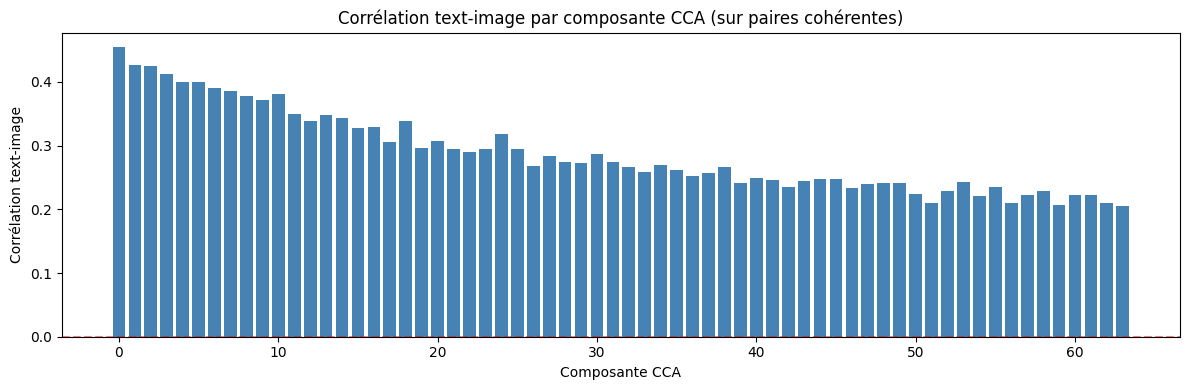

Corrélation moyenne : 0.288
Corrélation max     : 0.454


In [6]:
# Cell 5 — CCA : projection dans un espace commun
# Idée clé : entraîner la CCA UNIQUEMENT sur les paires cohérentes
# → elle apprend à aligner les espaces texte et image sur les vrais exemples
# Ensuite on projette TOUT le monde (cohérent + incohérent) dans cet espace

N_COMPONENTS = 64  # dimension de l'espace commun

print(f"Entraînement CCA sur {(y_train==1).sum()} paires cohérentes...")
cca = PLSCanonical(n_components=N_COMPONENTS, max_iter=1000)
cca.fit(E_text_train[y_train==1],   # textes cohérents
        E_img_train[y_train==1])    # images cohérentes

# Projection de tous les splits dans l'espace commun
T_text_train, T_img_train = cca.transform(E_text_train, E_img_train)
T_text_val,   T_img_val   = cca.transform(E_text_val,   E_img_val)
T_text_test,  T_img_test  = cca.transform(E_text_test,  E_img_test)

print(f"Shape après CCA: text={T_text_train.shape}, image={T_img_train.shape}")
print("Les deux espaces ont maintenant la même dimension !")

# Visualisation : corrélations par composante
correlations = [np.corrcoef(T_text_train[:,i], T_img_train[:,i])[0,1]
                for i in range(N_COMPONENTS)]
plt.figure(figsize=(12, 4))
plt.bar(range(N_COMPONENTS), correlations, color='steelblue')
plt.xlabel('Composante CCA')
plt.ylabel('Corrélation text-image')
plt.title('Corrélation text-image par composante CCA (sur paires cohérentes)')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print(f"Corrélation moyenne : {np.mean(correlations):.3f}")
print(f"Corrélation max     : {np.max(correlations):.3f}")


Construction des features géométriques...
Shape finale features: (7000, 324)
  Scalaires : 4 (distance, cosine, norm_ratio, projection)
  Vecteurs  : 192 (diff, product, abs_diff × 64)
  Embeddings: 128 (T_text + T_img × 64)


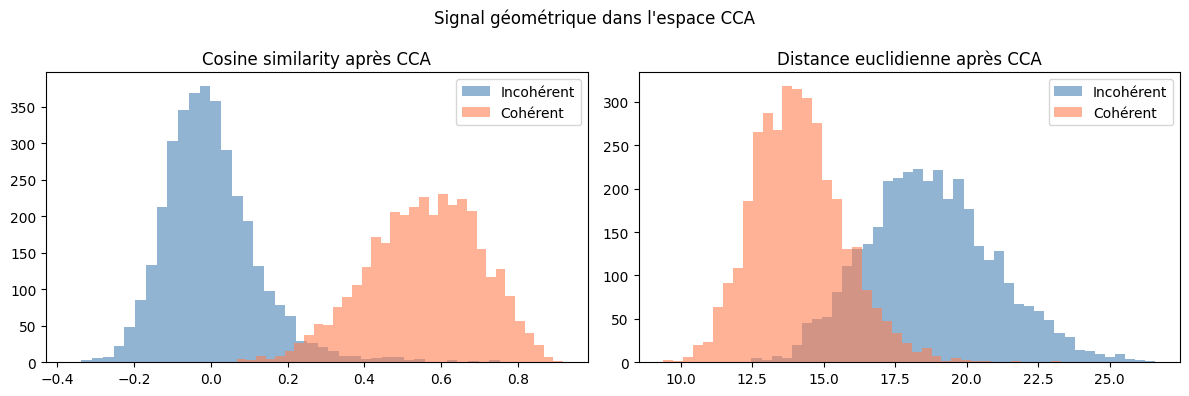

Si séparation visible → CCA a créé un espace aligné !


In [7]:
# Cell 6 — Features géométriques dans l'espace commun
# Le modèle apprend TOUTE la relation géométrique, pas juste la distance

def geometry_features(T_text, T_img):
    # 1. Distance euclidienne (magnitude de la différence)
    diff     = T_text - T_img                                          # (N, 64)
    distance = np.linalg.norm(diff, axis=1, keepdims=True)            # (N, 1)

    # 2. Cosine similarity (angle entre les vecteurs)
    norm_t   = np.linalg.norm(T_text, axis=1, keepdims=True) + 1e-8
    norm_i   = np.linalg.norm(T_img,  axis=1, keepdims=True) + 1e-8
    cos_sim  = (T_text * T_img).sum(axis=1, keepdims=True) / (norm_t * norm_i)  # (N, 1)

    # 3. Produit élément par élément (alignement par dimension)
    product  = T_text * T_img                                          # (N, 64)

    # 4. Différence absolue (désaccord par dimension)
    abs_diff = np.abs(diff)                                            # (N, 64)

    # 5. Ratio des normes (est-ce que les vecteurs ont la même magnitude ?)
    norm_ratio = norm_t / (norm_i + 1e-8)                             # (N, 1)

    # 6. Projection de text sur image (combien text "explique" image ?)
    projection = (T_text * T_img).sum(axis=1, keepdims=True) / (norm_i**2 + 1e-8)  # (N, 1)

    # 7. Vecteurs complets (le modèle apprend les patterns individuels aussi)
    return np.hstack([distance, cos_sim, norm_ratio, projection,
                      diff, product, abs_diff,
                      T_text, T_img])

print("Construction des features géométriques...")
X_train_raw = geometry_features(T_text_train, T_img_train)
X_val_raw   = geometry_features(T_text_val,   T_img_val)
X_test_raw  = geometry_features(T_text_test,  T_img_test)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Shape finale features: {X_train.shape}")
n_scalar = 4
n_vector = 3 * 64
n_full   = 2 * 64
print(f"  Scalaires : {n_scalar} (distance, cosine, norm_ratio, projection)")
print(f"  Vecteurs  : {n_vector} (diff, product, abs_diff × 64)")
print(f"  Embeddings: {n_full} (T_text + T_img × 64)")

# Visualisation signal
cos_train = (T_text_train * T_img_train).sum(axis=1) /             (np.linalg.norm(T_text_train, axis=1) *
             np.linalg.norm(T_img_train,  axis=1) + 1e-8)

dist_train = np.linalg.norm(T_text_train - T_img_train, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cos_train[y_train==0], bins=40, alpha=0.6, label='Incohérent', color='steelblue')
axes[0].hist(cos_train[y_train==1], bins=40, alpha=0.6, label='Cohérent',   color='coral')
axes[0].set_title('Cosine similarity après CCA')
axes[0].legend()

axes[1].hist(dist_train[y_train==0], bins=40, alpha=0.6, label='Incohérent', color='steelblue')
axes[1].hist(dist_train[y_train==1], bins=40, alpha=0.6, label='Cohérent',   color='coral')
axes[1].set_title('Distance euclidienne après CCA')
axes[1].legend()

plt.suptitle('Signal géométrique dans l\'espace CCA')
plt.tight_layout()
plt.show()
print("Si séparation visible → CCA a créé un espace aligné !")


In [8]:
# Cell 7 — Entraînement des modèles
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Linear SVM':          LinearSVC(max_iter=3000, C=1.0, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
print(f"{'Modèle':<25} {'CV (3-fold)':>12} {'±':>6} {'Val Acc':>10} {'Val F1':>10}")
print("-" * 68)
for name, model in models.items():
    print(f"  {name}...", end=' ', flush=True)
    cv = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=1)
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_pred)
    val_f1  = f1_score(y_val, y_pred)
    results[name] = {'cv_mean': cv.mean(), 'cv_std': cv.std(),
                     'val_accuracy': val_acc, 'val_f1': val_f1, 'model': model}
    print(f"CV: {cv.mean():.4f} ±{cv.std():.4f} | Val Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

results_df = pd.DataFrame(results).T[['cv_mean','cv_std','val_accuracy','val_f1']]
print("\n=== Meilleur modèle ===")
print(results_df.sort_values('val_accuracy', ascending=False).head(1))


Modèle                     CV (3-fold)      ±    Val Acc     Val F1
--------------------------------------------------------------------
  Logistic Regression... CV: 0.9574 ±0.0040 | Val Acc: 0.8360 | F1: 0.8150
  Linear SVM... CV: 0.9557 ±0.0033 | Val Acc: 0.8400 | F1: 0.8201
  Random Forest... CV: 0.9696 ±0.0022 | Val Acc: 0.8760 | F1: 0.8658

=== Meilleur modèle ===
                cv_mean    cv_std val_accuracy    val_f1
Random Forest  0.969572  0.002181        0.876  0.865801


  RÉSULTAT FINAL — CCA + Géométrie
  Modèle      : Random Forest
  Test Acc    : 0.8740
  Test F1     : 0.8609
              precision    recall  f1-score   support

  incohérent       0.82      0.97      0.88       752
    cohérent       0.96      0.78      0.86       748

    accuracy                           0.87      1500
   macro avg       0.89      0.87      0.87      1500
weighted avg       0.89      0.87      0.87      1500



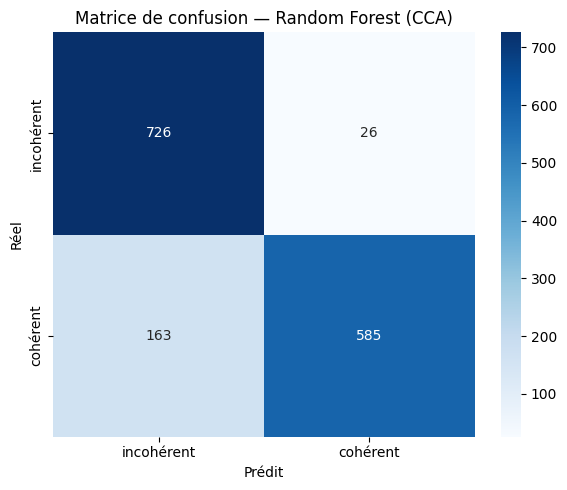

In [9]:
# Cell 8 — Évaluation finale
best_name  = results_df['val_accuracy'].idxmax()
best_model = results[best_name]['model']

y_pred   = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred)

print("=" * 50)
print(f"  RÉSULTAT FINAL — CCA + Géométrie")
print(f"  Modèle      : {best_name}")
print(f"  Test Acc    : {test_acc:.4f}")
print(f"  Test F1     : {test_f1:.4f}")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['incohérent','cohérent']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['incohérent','cohérent'],
            yticklabels=['incohérent','cohérent'])
plt.title(f'Matrice de confusion — {best_name} (CCA)')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout()
plt.show()


In [10]:
# Cell 9 — Sauvegarde
import joblib
joblib.dump(best_model, 'cca_best_model.pkl')
joblib.dump(scaler,     'cca_scaler.pkl')
joblib.dump(cca,        'cca_projector.pkl')
print("Sauvegardé : cca_best_model.pkl, cca_scaler.pkl, cca_projector.pkl")


Sauvegardé : cca_best_model.pkl, cca_scaler.pkl, cca_projector.pkl
